# DNN + Equação Linear Aproximada para fR,1 
Treina uma DNN e gera uma equação linear aproximada em **unidades originais**, para previsões interpretáveis.

In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 1. CARREGAR OS DADOS
df_temp = pd.read_excel("teste banco de dados.xlsx", header=None)
header_row = df_temp[df_temp.apply(lambda x: x.astype(str).str.contains("Tipo do concreto", case=False, na=False)).any(axis=1)].index[0]
df = pd.read_excel("teste banco de dados.xlsx", header=header_row)
df = df.dropna(axis=1, how="all")

In [37]:
# 2. DEFINIR FEATURES E TARGET
feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]
target_col = 'fR,1 (N/mm²)      (experimental)'

X = df[feature_cols].values
y = df[target_col].values

# 3. DIVIDIR TREINO/TESTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. NORMALIZAR DADOS PARA TREINAMENTO DNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
# 5. TREINAR DNN
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='linear')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
history = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=200, batch_size=16, verbose=1)

# Avaliar DNN
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"DNN - MAE: {mae:.4f}, Loss (MSE): {loss:.4f}")

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 30.5576 - mae: 4.9837 - val_loss: 25.7234 - val_mae: 4.4411
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 21.2152 - mae: 3.9595 - val_loss: 17.8221 - val_mae: 3.4285
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 11.8800 - mae: 2.7687 - val_loss: 10.6795 - val_mae: 2.6390
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.9404 - mae: 1.9079 - val_loss: 7.3774 - val_mae: 2.2790
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.0673 - mae: 1.6602 - val_loss: 6.3524 - val_mae: 2.1464
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.6052 - mae: 1.5353 - val_loss: 5.5749 - val_mae: 2.0025
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.1985 - mae: 1.4223 - val_loss: 5.2140 - val_mae: 1.9145
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.0440 - mae: 1.3899 - val_loss: 4.9494 - val_mae: 1.8589
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - l

In [39]:
# 6. GERAR PREVISÕES DA DNN PARA TODO DATASET (unidades originais)
X_scaled_full = scaler.transform(X)
y_pred_dnn_full = model.predict(X_scaled_full).flatten()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [40]:
# 7. TREINAR REGRESSÃO LINEAR SOBRE AS PREVISÕES DA DNN (unidades originais)
lin_approx = LinearRegression()
lin_approx.fit(X, y_pred_dnn_full)

intercept_approx = lin_approx.intercept_
coefs_approx = lin_approx.coef_

# Criar string legível da equação
equacao_str = f"fR = {intercept_approx:.5f}"
for c, f in zip(coefs_approx, feature_cols):
    equacao_str += f" + ({c:.5f} * {f})"

print("Equação linear aproximada da DNN (unidades originais):")
print(equacao_str)

Equação linear aproximada da DNN (unidades originais):
fR = -2.65228 + (0.06410 * fck (resistência)            [MPa]) + (0.00069 * l (comprimento)            [mm]) + (-1.04693 * d (diâmetro            [mm]) + (0.02488 * l/d      (fator de forma             ) + (6.16863 * Teor de fibra (%)) + (0.40285 * N (ganchos))


In [41]:
# 8. FUNÇÃO PARA CALCULAR fR COM EQUAÇÃO LINEAR APROXIMADA (unidades originais)
def calcular_fr(**kwargs):
    vals = np.array([kwargs[f] for f in feature_cols])
    return float(intercept_approx + np.dot(coefs_approx, vals))

print('Função calcular_fr habilitada.')

Função calcular_fr habilitada.


In [42]:
# 9. TESTAR EXEMPLO
valores_exemplo = {
    'fck (resistência)            [MPa]': 61.3,
    'l (comprimento)            [mm]': 35,
    'd (diâmetro            [mm]': 0.55,
    'l/d      (fator de forma             ': 63.64,
    'Teor de fibra (%)': 0.4,
    'N (ganchos)': 1
}
fR_previsto = calcular_fr(**valores_exemplo)
print(f'Valor previsto de fR = {fR_previsto:.4f}')

Valor previsto de fR = 5.1785


In [43]:
# 10. APLICAR A EQUAÇÃO EM TODO DATASET E COMPARAR
preds_approx = np.array([calcular_fr(**{f: row[f] for f in feature_cols}) for idx, row in df.iterrows()])

comparacao = df.copy()
comparacao['fR_previsto'] = preds_approx
print(comparacao[[target_col, 'fR_previsto']].head(10))

mse = mean_squared_error(df[target_col].values, preds_approx)
mae = mean_absolute_error(df[target_col].values, preds_approx)
r2 = r2_score(df[target_col].values, preds_approx)

print(f"\nMSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

   fR,1 (N/mm²)      (experimental)  fR_previsto
0                           4.99000      5.17856
1                           7.44000      7.80625
2                           5.35000      5.05210
3                           7.94000      7.20547
4                           5.49000      5.17856
5                           4.37000      5.17856
6                           4.67000      5.17856
7                           5.22000      5.17856
8                           4.74000      5.17856
9                           5.46000      5.17856

MSE: 1.4978
MAE: 0.9057
R²: 0.7737


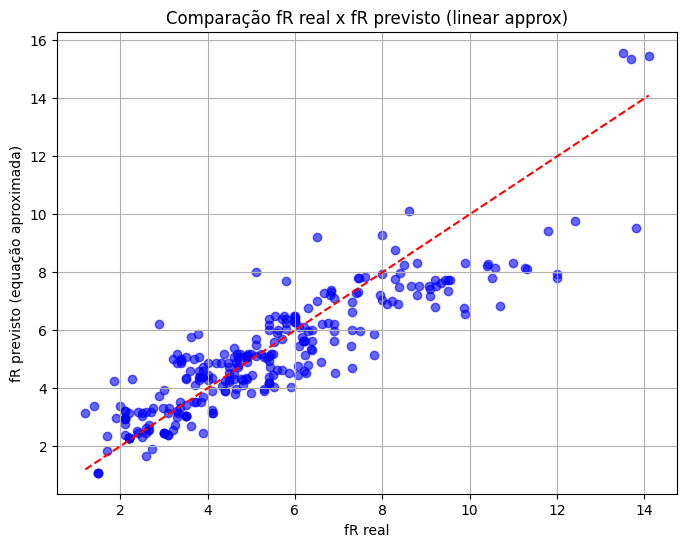

In [44]:
# 11. GRÁFICO fR REAL X fR PREVISTO
plt.figure(figsize=(8,6))
plt.scatter(df[target_col].values, preds_approx, alpha=0.6, color='blue')
plt.plot([df[target_col].min(), df[target_col].max()], [df[target_col].min(), df[target_col].max()], 'r--')
plt.xlabel('fR real')
plt.ylabel('fR previsto (equação aproximada)')
plt.title('Comparação fR real x fR previsto (linear approx)')
plt.grid(True)
plt.show()

Comparação com erro absoluto:
   fR,1 (N/mm²)      (experimental)  fR_previsto  Erro_absoluto
0                           4.99000      5.17856        0.18856
1                           7.44000      7.80625        0.36625
2                           5.35000      5.05210        0.29790
3                           7.94000      7.20547        0.73453
4                           5.49000      5.17856        0.31144
5                           4.37000      5.17856        0.80856
6                           4.67000      5.17856        0.50856
7                           5.22000      5.17856        0.04144
8                           4.74000      5.17856        0.43856
9                           5.46000      5.17856        0.28144

Estatísticas do erro absoluto:
count   281.00000
mean      0.90572
std       0.82455
min       0.00277
25%       0.30503
50%       0.61461
75%       1.30099
max       4.26748
Name: Erro_absoluto, dtype: float64


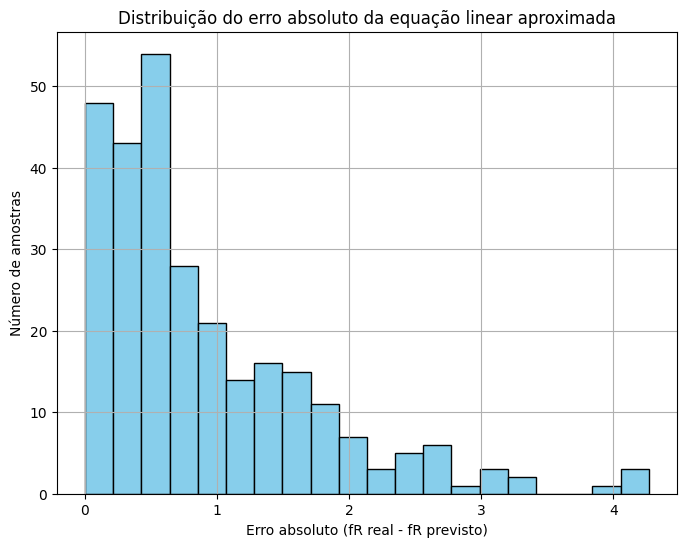

In [45]:
# 12. AVALIAÇÃO DETALHADA DO ERRO POR LINHA

# Calcular erro absoluto por linha
comparacao['Erro_absoluto'] = np.abs(comparacao[target_col] - comparacao['fR_previsto'])

# Mostrar as primeiras 10 linhas com erro
print("Comparação com erro absoluto:")
print(comparacao[[target_col, 'fR_previsto', 'Erro_absoluto']].head(10))

# Estatísticas gerais do erro
print("\nEstatísticas do erro absoluto:")
print(comparacao['Erro_absoluto'].describe())

# Plotar histograma do erro absoluto
plt.figure(figsize=(8,6))
plt.hist(comparacao['Erro_absoluto'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Erro absoluto (fR real - fR previsto)')
plt.ylabel('Número de amostras')
plt.title('Distribuição do erro absoluto da equação linear aproximada')
plt.grid(True)
plt.show()


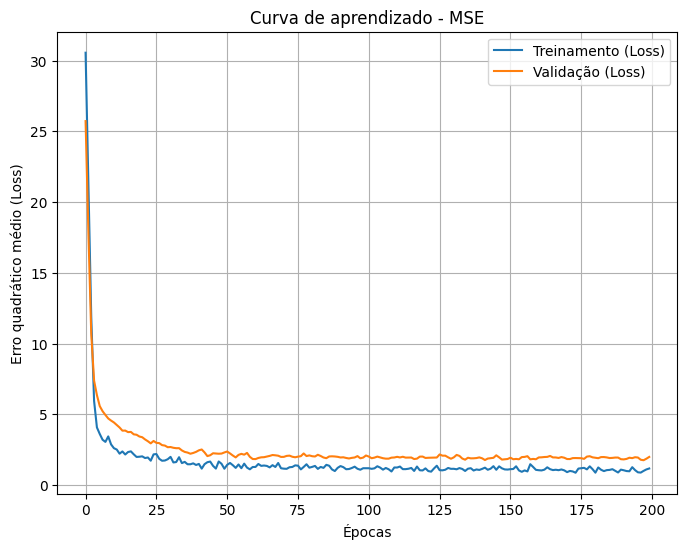

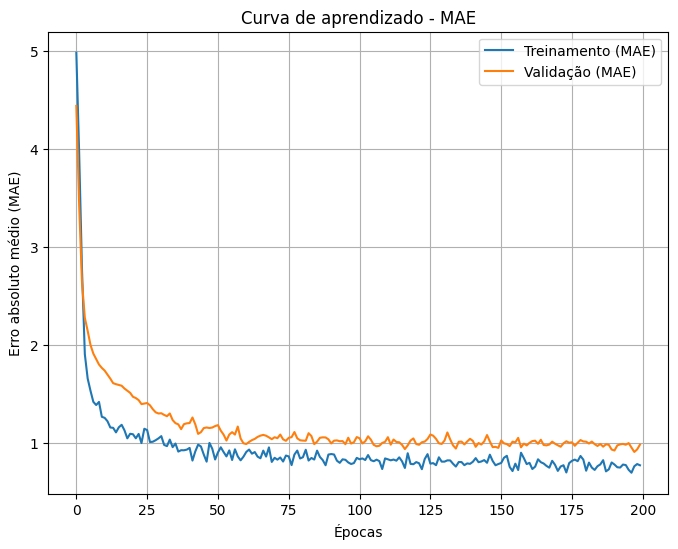

In [46]:
# 13. CURVAS DE TREINAMENTO DA DNN

import matplotlib.pyplot as plt

# Curva de aprendizado - Loss (MSE)
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Treinamento (Loss)')
plt.plot(history.history['val_loss'], label='Validação (Loss)')
plt.title('Curva de aprendizado - MSE')
plt.xlabel('Épocas')
plt.ylabel('Erro quadrático médio (Loss)')
plt.legend()
plt.grid(True)
plt.show()

# Curva de aprendizado - MAE
plt.figure(figsize=(8,6))
plt.plot(history.history['mae'], label='Treinamento (MAE)')
plt.plot(history.history['val_mae'], label='Validação (MAE)')
plt.title('Curva de aprendizado - MAE')
plt.xlabel('Épocas')
plt.ylabel('Erro absoluto médio (MAE)')
plt.legend()
plt.grid(True)
plt.show()


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from lazypredict.Supervised import LazyClassifier

import warnings
warnings.filterwarnings('ignore')

CARREGANDO E PREPARANDO OS DADOS
Cabeçalho encontrado na linha: 5

Colunas disponíveis (16):
    0. 'Unnamed: 0'
    1. 'Unnamed: 1'
    2. 'Unnamed: 2'
    3. 'Tipo do concreto'
    4. 'fck (resistência)            [MPa]'
    5. 'l (comprimento)            [mm]'
    6. 'd (diâmetro            [mm]'
    7. 'l/d      (fator de forma'
    8. 'Teor de fibra (%)'
    9. 'N (ganchos)'
   10. 'fR,1 (N/mm²)      (experimental)'
   11. 'fR,3 (N/mm²)      (experimental)'
   12. 'Unnamed: 12'
   13. 'Unnamed: 13'
   14. 'Unnamed: 14'
   15. 'Unnamed: 15'

Colunas identificadas:
  Target (fR,1): fR,1 (N/mm²)      (experimental)
  fck: fck (resistência)            [MPa]
  l: l (comprimento)            [mm]
  d: d (diâmetro            [mm]
  l/d: l/d      (fator de forma
  Teor de fibra: Teor de fibra (%)
  N ganchos: N (ganchos)
  Tipo: Tipo do concreto

DataFrame criado com 281 linhas e 7 colunas

Convertendo dados para numérico...

Removidas 0 linhas com valores NaN
Dados finais: 281 amostras

E

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 112, number of negative: 112
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000034 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 126
[LightGBM] [Info] Number of data points in the train set: 224, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

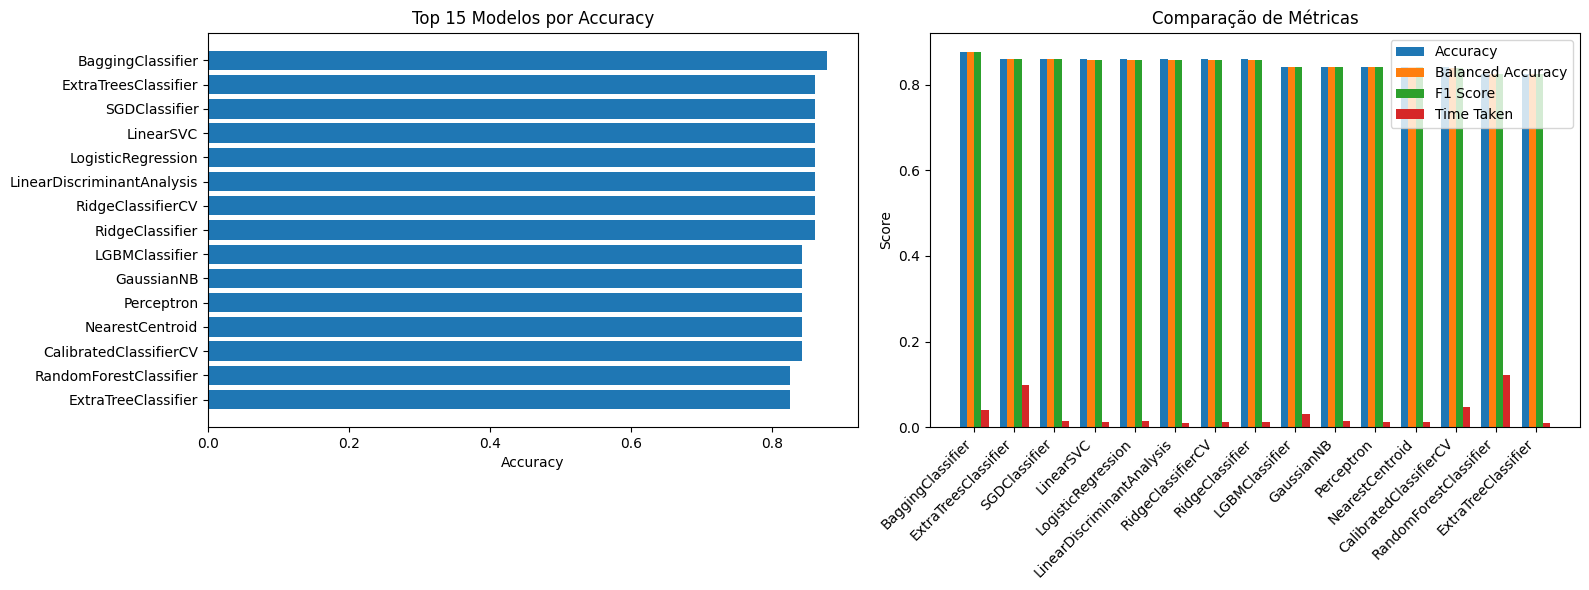


Matriz de confusão para: BaggingClassifier
Modelo 'BaggingClassifier' não encontrado

ANÁLISE DE CORRELAÇÃO


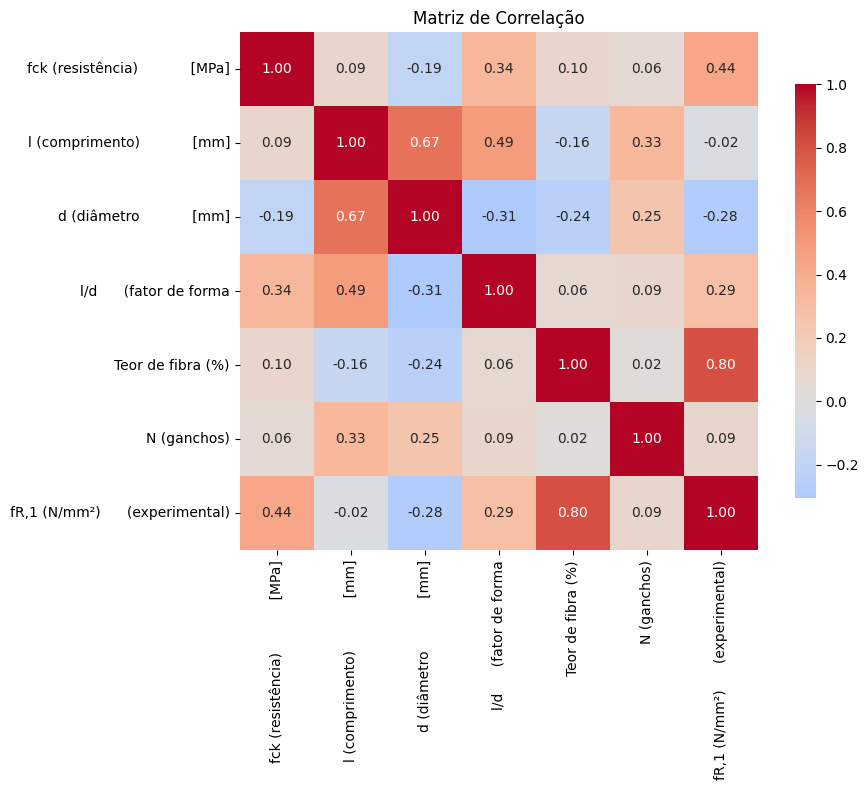


CORRELAÇÃO COM fR,1:
   Teor de fibra (%): 0.8013 (ALTA correlação positiva)
   fck (resistência)            [MPa]: 0.4379 (MÉDIA correlação positiva)
   l/d      (fator de forma: 0.2852 (BAIXA correlação positiva)
   N (ganchos): 0.0895 (BAIXA correlação positiva)
   l (comprimento)            [mm]: -0.0241 (BAIXA correlação negativa)
   d (diâmetro            [mm]: -0.2810 (BAIXA correlação negativa)

RESUMO FINAL

MELHOR MODELO: BaggingClassifier
   Accuracy: 0.8772
   Balanced Accuracy: 0.8768
   F1 Score: 0.8771
   Time Taken: 0.0401

DISTRIBUIÇÃO DAS CLASSES:
   Low_fR1: 141 amostras (50.2%)
   High_fR1: 140 amostras (49.8%)

INFORMAÇÕES TÉCNICAS:
   Total de amostras: 281
   Features usadas: 6
   Tamanho treino: 224
   Tamanho teste: 57

SALVANDO RESULTADOS...
Resultados salvos em 'resultados_concreto.csv'
Resultados salvos em 'resultados_concreto.xlsx'
Dados processados salvos em 'dados_concreto_processados.csv'

ANÁLISE CONCLUÍDA

ESTATÍSTICAS DESCRITIVAS COMPLETAS:
       fc

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from lazypredict.Supervised import LazyClassifier

import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CARREGAR E PREPARAR OS DADOS - VERSÃO AJUSTADA
# ============================================================================

print("=" * 80)
print("CARREGANDO E PREPARANDO OS DADOS")
print("=" * 80)

# Carregar dados brutos para encontrar o cabeçalho correto
df_raw = pd.read_excel("teste banco de dados.xlsx", header=None)

# Encontrar a linha com "Tipo do concreto"
header_idx = None
for i in range(min(20, len(df_raw))):  # Verificar as primeiras 20 linhas
    if df_raw.iloc[i].astype(str).str.contains("Tipo do concreto", case=False, na=False).any():
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Cabeçalho 'Tipo do concreto' não encontrado!")

print(f"Cabeçalho encontrado na linha: {header_idx}")

# Carregar dados com cabeçalho correto
df = pd.read_excel("teste banco de dados.xlsx", header=header_idx)

# Limpar nomes das colunas
df.columns = df.columns.str.strip()

# Mostrar informações sobre as colunas
print(f"\nColunas disponíveis ({len(df.columns)}):")
for i, col in enumerate(df.columns):
    print(f"  {i:3d}. '{col}'")

# ============================================================================
# IDENTIFICAR COLUNAS IMPORTANTES
# ============================================================================

# Mapear possíveis nomes de colunas
col_mapping = {
    'fck': ['fck', 'fck (resistência)', 'fck             [MPa]'],
    'l': ['l (comprimento)', 'l             [mm]', 'comprimento'],
    'd': ['d (diâmetro', 'd             [mm]', 'diâmetro'],
    'l/d': ['l/d', 'l/d      (fator de forma', 'l/d             '],
    'fibra': ['Teor de fibra (%)', 'Teor de fibra'],
    'ganchos': ['N (ganchos)', 'ganchos'],
    'fR1': ['fR,1 (N/mm²)      (experimental)', 'fR,1', 'fR1'],
    'fR3': ['fR,3 (N/mm²)      (experimental)', 'fR,3', 'fR3'],
    'tipo': ['Tipo do concreto', 'Tipo']
}

# Função para encontrar coluna
def find_column(possible_names):
    for name in possible_names:
        for col in df.columns:
            if name.lower() in str(col).lower():
                return col
    return None

# Encontrar colunas
target_col = find_column(col_mapping['fR1'])
fck_col = find_column(col_mapping['fck'])
l_col = find_column(col_mapping['l'])
d_col = find_column(col_mapping['d'])
ld_col = find_column(col_mapping['l/d'])
fibra_col = find_column(col_mapping['fibra'])
ganchos_col = find_column(col_mapping['ganchos'])
tipo_col = find_column(col_mapping['tipo'])

print(f"\nColunas identificadas:")
print(f"  Target (fR,1): {target_col}")
print(f"  fck: {fck_col}")
print(f"  l: {l_col}")
print(f"  d: {d_col}")
print(f"  l/d: {ld_col}")
print(f"  Teor de fibra: {fibra_col}")
print(f"  N ganchos: {ganchos_col}")
print(f"  Tipo: {tipo_col}")

# ============================================================================
# CRIAR DATAFRAME PARA ANÁLISE
# ============================================================================

# Verificar se encontramos as colunas necessárias
if not all([target_col, fck_col, l_col, d_col, ld_col, fibra_col, ganchos_col]):
    print("\nAVISO: Algumas colunas não foram encontradas!")
    print("Usando todas as colunas numéricas...")
    
    # Selecionar apenas colunas numéricas
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    if target_col:
        # Remover target das features se ele for numérico
        if target_col in numeric_cols:
            numeric_cols.remove(target_col)
        
        feature_cols = numeric_cols
    else:
        print("ERRO: Coluna target não encontrada!")
        # Tentar usar a primeira coluna numérica como target
        if len(numeric_cols) > 0:
            target_col = numeric_cols[0]
            feature_cols = numeric_cols[1:]
            print(f"  Usando '{target_col}' como target")
else:
    # Usar colunas específicas
    feature_cols = [fck_col, l_col, d_col, ld_col, fibra_col, ganchos_col]

# Criar DataFrame de trabalho
if target_col in df.columns:
    concrete_df = df[feature_cols + [target_col]].copy()
else:
    concrete_df = df[feature_cols].copy()
    print("AVISO: Target não incluído no DataFrame")

print(f"\nDataFrame criado com {len(concrete_df)} linhas e {len(concrete_df.columns)} colunas")

# ============================================================================
# LIMPEZA E CONVERSÃO DOS DADOS
# ============================================================================

# Converter todas as colunas para numérico (tratar fórmulas e erros)
print("\nConvertendo dados para numérico...")
for col in concrete_df.columns:
    concrete_df[col] = pd.to_numeric(concrete_df[col], errors='coerce')
    na_count = concrete_df[col].isna().sum()
    if na_count > 0:
        print(f"  {col}: {na_count} valores não numéricos convertidos para NaN")

# Remover linhas com valores NaN
initial_rows = len(concrete_df)
concrete_df = concrete_df.dropna()
final_rows = len(concrete_df)
print(f"\nRemovidas {initial_rows - final_rows} linhas com valores NaN")
print(f"Dados finais: {final_rows} amostras")

# Verificar se temos dados suficientes
if len(concrete_df) < 10:
    print("\nERRO: Dados insuficientes após limpeza!")
    print("Mostrando primeiras linhas para diagnóstico:")
    print(concrete_df.head())
    raise ValueError("Dados insuficientes para análise")

# ============================================================================
# ESTATÍSTICAS INICIAIS
# ============================================================================

print(f"\nESTATÍSTICAS DO DATASET:")
print(f"  Amostras: {len(concrete_df)}")
print(f"  Features: {len(feature_cols)}")

if target_col in concrete_df.columns:
    print(f"\nESTATÍSTICAS DO TARGET '{target_col}':")
    print(f"  Média: {concrete_df[target_col].mean():.4f}")
    print(f"  Mediana: {concrete_df[target_col].median():.4f}")
    print(f"  Mínimo: {concrete_df[target_col].min():.4f}")
    print(f"  Máximo: {concrete_df[target_col].max():.4f}")
    print(f"  Desvio padrão: {concrete_df[target_col].std():.4f}")

# Mostrar primeiras linhas
print(f"\nPRIMEIRAS 5 LINHAS DOS DADOS:")
print(concrete_df.head())

# ============================================================================
# CLASSE CLASSIFICADORA (MANTIDA SUA VERSÃO ORIGINAL)
# ============================================================================

class ConcretePropertiesClassifier:
    def __init__(self, data, target_column, test_size=0.2, random_state=42):
        """
        Classificador para propriedades do concreto com fibras
        """
        self.data = data.copy()
        self.target_column = target_column
        self.test_size = test_size
        self.random_state = random_state
        
        # Pré-processamento
        self._prepare_target()
        
        # Separar features e target
        self.features = self.data.drop(self.target_column, axis=1)
        self.targets = self.data[self.target_column]
        
        # Split dos dados
        self.features_train, self.features_test, self.targets_train, self.targets_test = train_test_split(
            self.features, self.targets, 
            test_size=self.test_size, 
            random_state=self.random_state, 
            stratify=self.targets
        )
        
        # Inicializar LazyClassifier
        self.lazyClassifier = LazyClassifier(
            verbose=0, 
            ignore_warnings=True, 
            custom_metric=None,
            random_state=self.random_state
        )
        self.models = None
        self.predictions = None
        
    def _prepare_target(self):
        """Converter variável contínua em categórica para classificação"""
        if self.target_column in self.data.columns:
            threshold = self.data[self.target_column].median()
            self.data[self.target_column] = np.where(
                self.data[self.target_column] > threshold, 
                'High_fR1', 
                'Low_fR1'
            )
            print(f"\nTarget convertido para classificação binária")
            print(f"   Threshold (mediana): {threshold:.4f}")
            print(f"   Distribuição: {self.data[self.target_column].value_counts().to_dict()}")
        else:
            print(f"Coluna '{self.target_column}' não encontrada")
            
    def fit(self):
        """Treinar múltiplos modelos"""
        print("\nTreinando modelos com LazyClassifier...")
        self.models, self.predictions = self.lazyClassifier.fit(
            self.features_train, self.features_test, 
            self.targets_train, self.targets_test
        )
        print("Treinamento concluído!")
        return self.models
        
    def get_models(self):
        """Retornar resultados dos modelos"""
        return self.models
        
    def get_predictions(self):
        """Retornar predições"""
        return self.predictions
    
    def plot_confusion_matrix(self, model_name=None):
        """Plotar matriz de confusão"""
        if self.predictions is None:
            print("Treine os modelos primeiro!")
            return
        
        if model_name is None:
            model_name = self.models.index[0] if self.models is not None else 'Logistic Regression'
        
        if model_name not in self.predictions.columns:
            print(f"Modelo '{model_name}' não encontrado")
            return
        
        y_pred = self.predictions[model_name]
        cm = confusion_matrix(self.targets_test, y_pred)
        
        fig, ax = plt.subplots(figsize=(8, 6))
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=['Low_fR1', 'High_fR1']
        )
        disp.plot(ax=ax, cmap='Blues')
        plt.title(f'Matriz de Confusão - {model_name}')
        plt.show()
        
    def plot_model_comparison(self, top_n=15):
        """Plotar comparação dos modelos"""
        if self.models is None:
            print("Treine os modelos primeiro!")
            return
        
        # Filtrar valores None e pegar top_n modelos
        top_models = self.models.head(top_n).copy()
        
        # Remover colunas com todos valores None
        top_models = top_models.dropna(axis=1, how='all')
        
        # Substituir valores None restantes por 0 para plotagem
        top_models = top_models.fillna(0)
        
        if len(top_models.columns) == 0:
            print("Nenhuma métrica disponível para plotar")
            return
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Gráfico 1: Usar a primeira métrica numérica disponível
        numeric_cols = top_models.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) == 0:
            print("Nenhuma métrica numérica disponível")
            return
        
        primary_metric = numeric_cols[0]
        axes[0].barh(range(len(top_models)), top_models[primary_metric])
        axes[0].set_yticks(range(len(top_models)))
        axes[0].set_yticklabels(top_models.index)
        axes[0].set_xlabel(primary_metric)
        axes[0].set_title(f'Top {len(top_models)} Modelos por {primary_metric}')
        axes[0].invert_yaxis()
        
        # Gráfico 2: Comparação de múltiplas métricas numéricas
        metrics_to_plot = numeric_cols[:4]  # Plotar no máximo 4 métricas
        if len(metrics_to_plot) > 1:
            x = np.arange(len(top_models))
            width = 0.18
            
            for i, metric in enumerate(metrics_to_plot):
                axes[1].bar(x + i*width, top_models[metric], width, label=metric)
            
            axes[1].set_xticks(x + width*(len(metrics_to_plot)-1)/2)
            axes[1].set_xticklabels(top_models.index, rotation=45, ha='right')
            axes[1].set_ylabel('Score')
            axes[1].set_title('Comparação de Métricas')
            axes[1].legend()
        else:
            axes[1].text(0.5, 0.5, f'Apenas {primary_metric} disponível', 
                        ha='center', va='center', fontsize=12)
            axes[1].set_title('Informação de Métricas')
            axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()

# ============================================================================
# EXECUTAR ANÁLISE
# ============================================================================

if target_col in concrete_df.columns:
    print("\n" + "=" * 80)
    print("INICIANDO ANÁLISE DE CLASSIFICAÇÃO")
    print("=" * 80)
    
    # Criar e treinar classificador
    concreteClassifier = ConcretePropertiesClassifier(
        data=concrete_df,
        target_column=target_col,
        test_size=0.2,
        random_state=42
    )
    
    # Treinar
    models = concreteClassifier.fit()
    
    # ============================================================================
    # MOSTRAR RESULTADOS
    # ============================================================================
    
    if models is not None:
        # Limpar modelos (remover colunas com todos valores None)
        models_clean = models.copy()
        models_clean = models_clean.dropna(axis=1, how='all')
        
        print(f"\nCOLUNAS DISPONÍVEIS NOS RESULTADOS:")
        print(models_clean.columns.tolist())
        
        print(f"\nTOP 10 MODELOS:")
        
        # Mostrar apenas colunas numéricas
        numeric_cols = models_clean.select_dtypes(include=[np.number]).columns
        
        if len(numeric_cols) > 0:
            # Ordenar pela primeira métrica numérica disponível
            sort_by = numeric_cols[0]
            top_10 = models_clean.sort_values(sort_by, ascending=False).head(10)
            
            # Formatar para mostrar 5 casas decimais
            pd.set_option('display.float_format', lambda x: f'{x:.5f}')
            print(top_10[numeric_cols])
        else:
            print("Nenhuma métrica numérica disponível")
            print(models_clean.head(10))
        
        # Mostrar todos os modelos
        print(f"\nTODOS OS {len(models_clean)} MODELOS TESTADOS:")
        if len(numeric_cols) > 0:
            # Ordenar pela melhor métrica
            all_models_sorted = models_clean.sort_values(numeric_cols[0], ascending=False)
            print(all_models_sorted[numeric_cols])
        else:
            print(models_clean)
        
        # Plotar gráficos
        print("\nGERANDO GRÁFICOS...")
        concreteClassifier.plot_model_comparison(top_n=15)
        
        # Matriz de confusão
        if concreteClassifier.predictions is not None:
            best_model_name = models_clean.index[0]
            print(f"\nMatriz de confusão para: {best_model_name}")
            concreteClassifier.plot_confusion_matrix(model_name=best_model_name)
        
        # ANÁLISE DE CORRELAÇÃO
        print("\n" + "=" * 80)
        print("ANÁLISE DE CORRELAÇÃO")
        print("=" * 80)
        
        correlation_matrix = concrete_df.corr()
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                    fmt='.2f', square=True, cbar_kws={"shrink": 0.8})
        plt.title('Matriz de Correlação')
        plt.tight_layout()
        plt.show()
        
        # Correlação com target
        print("\nCORRELAÇÃO COM fR,1:")
        if target_col in correlation_matrix.columns:
            target_corr = correlation_matrix[target_col].sort_values(ascending=False)
            for feature, corr in target_corr.items():
                if feature != target_col:
                    importance = "ALTA" if abs(corr) > 0.5 else "MÉDIA" if abs(corr) > 0.3 else "BAIXA"
                    direction = "positiva" if corr > 0 else "negativa"
                    print(f"   {feature}: {corr:.4f} ({importance} correlação {direction})")
        
        # RESUMO FINAL
        print("\n" + "=" * 80)
        print("RESUMO FINAL")
        print("=" * 80)
        
        if len(numeric_cols) > 0:
            best_model = models_clean.iloc[0]
            print(f"\nMELHOR MODELO: {best_model.name}")
            
            # Mostrar todas as métricas numéricas disponíveis
            for metric in numeric_cols:
                value = best_model[metric]
                print(f"   {metric}: {value:.4f}")
        
        # Distribuição das classes
        class_dist = concreteClassifier.data[target_col].value_counts()
        print(f"\nDISTRIBUIÇÃO DAS CLASSES:")
        for cls, count in class_dist.items():
            percentage = (count / len(concreteClassifier.data)) * 100
            print(f"   {cls}: {count} amostras ({percentage:.1f}%)")
        
        # Informações do dataset
        print(f"\nINFORMAÇÕES TÉCNICAS:")
        print(f"   Total de amostras: {len(concrete_df)}")
        print(f"   Features usadas: {len(feature_cols)}")
        print(f"   Tamanho treino: {len(concreteClassifier.features_train)}")
        print(f"   Tamanho teste: {len(concreteClassifier.features_test)}")
        
        # Salvar resultados
        print("\nSALVANDO RESULTADOS...")
        models_clean.to_csv('resultados_concreto.csv')
        print("Resultados salvos em 'resultados_concreto.csv'")
        
        # Salvar também em Excel para melhor formatação
        models_clean.to_excel('resultados_concreto.xlsx')
        print("Resultados salvos em 'resultados_concreto.xlsx'")
        
        # Salvar dados processados
        concrete_df.to_csv('dados_concreto_processados.csv', index=False)
        print("Dados processados salvos em 'dados_concreto_processados.csv'")
        
    else:
        print("Nenhum modelo foi treinado")

    print("\n" + "=" * 80)
    print("ANÁLISE CONCLUÍDA")
    print("=" * 80)

    # Mostrar estatísticas descritivas
    print("\nESTATÍSTICAS DESCRITIVAS COMPLETAS:")
    print(concrete_df.describe())
    
else:
    print("\n" + "=" * 80)
    print("AVISO: ANÁLISE NÃO REALIZADA")
    print("=" * 80)
    print("A coluna target não foi encontrada ou incluída no DataFrame.")
    print("\nColunas disponíveis no DataFrame:")
    for col in concrete_df.columns:
        print(f"  - {col}")

In [54]:
# ==============================================================================
# CONCRETE FIBER PROPERTIES ANALYZER - CLASSIFICAÇÃO E REGRESSÃO
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, r2_score, mean_squared_error, mean_absolute_error
from lazypredict.Supervised import LazyClassifier, LazyRegressor
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# CLASSE COMPLETA PARA ANÁLISE DE CONCRETO - VERSÃO AJUSTADA
# ==============================================================================
class ConcreteFiberAnalyzer:
    """
    Analisador completo para dados de concreto com fibras
    Faz tanto classificação quanto regressão
    """
    
    def __init__(self, data, target_column, feature_columns=None,
                 test_size=0.2, random_state=42):
        """
        Inicializa o analisador de concreto
        
        Parameters:
        -----------
        data : DataFrame
            Dados de concreto
        target_column : str
            Nome da coluna target
        feature_columns : list, optional
            Lista de colunas features
        test_size : float
            Proporção para teste
        random_state : int
            Seed para reprodutibilidade
        """
        self.data = data.copy()
        self.target_column = target_column
        self.test_size = test_size
        self.random_state = random_state
        
        # Limpar nomes das colunas (remover espaços extras)
        self.data.columns = self.data.columns.str.strip()
        
        # Mapear nomes de colunas com espaços
        self._map_column_names()
        
        # Definir colunas features padrão
        if feature_columns is None:
            self.feature_columns = [
                'fck             [MPa]',
                'l             [mm]',
                'd             [mm]',
                'l/d             ',
                'Teor de fibra (%)',
                'N (ganchos)'
            ]
            # Procurar colunas equivalentes
            self.feature_columns = self._find_columns(self.feature_columns)
        else:
            self.feature_columns = self._find_columns(feature_columns)
        
        # Ajustar nome do target também
        self.target_column = self._find_column(target_column)
        
        if not self.target_column:
            raise ValueError(f"Coluna target '{target_column}' não encontrada!")
        
        print(f"✅ Target identificado: {self.target_column}")
        print(f"✅ Features identificadas: {self.feature_columns}")
        
        # Preparar dados
        self._prepare_data()
        
        # Resultados
        self.classification_models = None
        self.regression_models = None
        self.classification_predictions = None
        self.regression_predictions = None
        self.y_test = None  # Para armazenar y_test da regressão
        
    def _map_column_names(self):
        """Mapeia e padroniza nomes de colunas"""
        # Dicionário de mapeamento de colunas
        self.column_map = {
            # Target columns
            'fR,1 (N/mm²)      (experimental)': 'fR1_experimental',
            'fR,3 (N/mm²)      (experimental)': 'fR3_experimental',
            
            # Feature columns
            'fck (resistência)            [MPa]': 'fck_MPa',
            'l (comprimento)            [mm]': 'length_mm',
            'd (diâmetro            [mm]': 'diameter_mm',
            'l/d      (fator de forma': 'l_d_ratio',
            'Teor de fibra (%)': 'fiber_percentage',
            'N (ganchos)': 'hooks_number',
            
            # Tipos de concreto
            'Tipo do concreto': 'concrete_type',
            
            # Colunas calculadas
            '=9.836*(E7^0.469)*((I7/100)^0.7235)*((H7)^0.3153)*(1+0.03173*J7^2)': 'predicted_fR',
            '=ABS(K7-N7)/K7': 'absolute_error',
            '=IF(O7>20%,"erro alto")': 'error_classification'
        }
        
        # Aplicar mapeamento
        new_columns = []
        for col in self.data.columns:
            if col in self.column_map:
                new_columns.append(self.column_map[col])
            else:
                # Simplificar nomes longos
                simplified = str(col).strip()
                # Remover espaços extras no meio
                simplified = ' '.join(simplified.split())
                # Substituir caracteres especiais
                simplified = simplified.replace('/', '_').replace('(', '').replace(')', '')
                simplified = simplified.replace('[', '').replace(']', '').replace('%', 'percent')
                new_columns.append(simplified)
        
        self.data.columns = new_columns
        
    def _find_column(self, column_name):
        """Encontra uma coluna (tratando espaços e variações)"""
        column_name = str(column_name).strip().lower()
        
        for col in self.data.columns:
            col_clean = str(col).strip().lower()
            if column_name in col_clean or col_clean in column_name:
                return col
        
        # Tentar encontrar por partes
        for col in self.data.columns:
            col_clean = str(col).strip().lower()
            # Verificar se palavras-chave estão presentes
            keywords = ['fR,1', 'fR1', 'experimental']
            if any(keyword.lower() in col_clean for keyword in keywords):
                return col
        
        return None
    
    def _find_columns(self, column_list):
        """Encontra múltiplas colunas"""
        found_columns = []
        for col in column_list:
            found_col = self._find_column(col)
            if found_col:
                found_columns.append(found_col)
            else:
                print(f"⚠️  Coluna não encontrada: {col}")
        
        return found_columns
    
    def _prepare_data(self):
        """Prepara dados para análise"""
        print("\n🔧 PREPARANDO DADOS...")
        
        # Verificar se as colunas existem
        all_columns = self.feature_columns + [self.target_column]
        missing_columns = [col for col in all_columns if col not in self.data.columns]
        
        if missing_columns:
            print(f"⚠️  Colunas ausentes: {missing_columns}")
            print(f"   Colunas disponíveis: {list(self.data.columns)}")
            raise ValueError(f"Colunas necessárias não encontradas: {missing_columns}")
        
        # Selecionar colunas necessárias
        self.data = self.data[all_columns].copy()
        
        print(f"📊 Formato inicial: {self.data.shape}")
        
        # Converter para numérico
        for col in self.data.columns:
            initial_non_numeric = self.data[col].apply(lambda x: not isinstance(x, (int, float, np.number))).sum()
            self.data[col] = pd.to_numeric(self.data[col], errors='coerce')
            final_nan = self.data[col].isna().sum()
            
            if initial_non_numeric > 0 or final_nan > 0:
                print(f"   Convertido '{col}': {initial_non_numeric} valores não numéricos")
        
        # Remover valores nulos
        initial_rows = len(self.data)
        self.data = self.data.dropna()
        removed_rows = initial_rows - len(self.data)
        
        if removed_rows > 0:
            print(f"   Removidas {removed_rows} linhas com valores nulos")
        
        print(f"✅ Dados preparados: {len(self.data)} amostras, {len(self.feature_columns)} features")
        
        # Estatísticas do target
        print(f"📊 ESTATÍSTICAS DO TARGET '{self.target_column}':")
        print(f"   Média: {self.data[self.target_column].mean():.4f}")
        print(f"   Mediana: {self.data[self.target_column].median():.4f}")
        print(f"   Min: {self.data[self.target_column].min():.4f}")
        print(f"   Max: {self.data[self.target_column].max():.4f}")
        print(f"   Desvio padrão: {self.data[self.target_column].std():.4f}")
        print(f"   Coeficiente de variação: {(self.data[self.target_column].std() / self.data[self.target_column].mean() * 100):.2f}%")
    
    def run_classification(self):
        """Executa análise de classificação (High/Low)"""
        print("\n" + "=" * 80)
        print("ANÁLISE DE CLASSIFICAÇÃO (High/Low)")
        print("=" * 80)
        
        # Verificar se temos dados suficientes
        if len(self.data) < 10:
            print("❌ Dados insuficientes para classificação (mínimo 10 amostras)")
            return None
        
        # Criar variável categórica
        data_clf = self.data.copy()
        threshold = data_clf[self.target_column].median()
        data_clf['Target_class'] = np.where(
            data_clf[self.target_column] > threshold,
            'High',
            'Low'
        )
        
        print(f"📈 Threshold (mediana): {threshold:.4f}")
        class_distribution = data_clf['Target_class'].value_counts().to_dict()
        print(f"📊 Distribuição: {class_distribution}")
        
        # Verificar balanceamento
        for cls, count in class_distribution.items():
            percentage = (count / len(data_clf)) * 100
            print(f"   {cls}: {count} amostras ({percentage:.1f}%)")
        
        if abs(class_distribution.get('High', 0) - class_distribution.get('Low', 0)) > len(data_clf) * 0.7:
            print("⚠️  Aviso: Dataset muito desbalanceado!")
        
        # Separar features e target
        X = data_clf[self.feature_columns]
        y = data_clf['Target_class']
        
        # Split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state, stratify=y
        )
        
        print(f"\n📊 SPLIT DOS DADOS:")
        print(f"   Treino: {len(X_train)} amostras ({len(X_train)/len(data_clf)*100:.1f}%)")
        print(f"   Teste: {len(X_test)} amostras ({len(X_test)/len(data_clf)*100:.1f}%)")
        print(f"   Features: {len(self.feature_columns)}")
        
        # Treinar com LazyClassifier
        print("\n🚀 TREINANDO MODELOS DE CLASSIFICAÇÃO...")
        try:
            clf = LazyClassifier(
                verbose=0, 
                ignore_warnings=True, 
                custom_metric=None,
                random_state=self.random_state,
                predictions=True
            )
            self.classification_models, self.classification_predictions = clf.fit(
                X_train, X_test, y_train, y_test
            )
            
            print("✅ CLASSIFICAÇÃO CONCLUÍDA!")
            return self.classification_models
            
        except Exception as e:
            print(f"❌ Erro na classificação: {e}")
            return None
    
    def run_regression(self):
        """Executa análise de regressão (valor exato)"""
        print("\n" + "=" * 80)
        print("ANÁLISE DE REGRESSÃO (valor exato)")
        print("=" * 80)
        
        # Verificar se temos dados suficientes
        if len(self.data) < 10:
            print("❌ Dados insuficientes para regressão (mínimo 10 amostras)")
            return None
        
        # Separar features e target
        X = self.data[self.feature_columns]
        y = self.data[self.target_column]
        
        # Split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state
        )
        
        # Armazenar y_test para uso posterior
        self.y_test = y_test
        
        print(f"📊 SPLIT DOS DADOS:")
        print(f"   Treino: {len(X_train)} amostras ({len(X_train)/len(self.data)*100:.1f}%)")
        print(f"   Teste: {len(X_test)} amostras ({len(X_test)/len(self.data)*100:.1f}%)")
        print(f"   Target: {self.target_column}")
        print(f"   Features: {self.feature_columns}")
        
        # Treinar com LazyRegressor
        print("\n🚀 TREINANDO MODELOS DE REGRESSÃO...")
        try:
            reg = LazyRegressor(
                verbose=0, 
                ignore_warnings=True, 
                custom_metric=None,
                random_state=self.random_state,
                predictions=True
            )
            self.regression_models, self.regression_predictions = reg.fit(
                X_train, X_test, y_train, y_test
            )
            
            print("✅ REGRESSÃO CONCLUÍDA!")
            return self.regression_models
            
        except Exception as e:
            print(f"❌ Erro na regressão: {e}")
            return None
    
    def get_top_classification_models(self, n=10, metric='Accuracy'):
        """Retorna top n modelos de classificação"""
        if self.classification_models is None:
            print("❌ Execute primeiro run_classification()")
            return None
        
        if metric in self.classification_models.columns:
            return self.classification_models.sort_values(metric, ascending=False).head(n)
        else:
            print(f"❌ Métrica '{metric}' não encontrada")
            print(f"   Métricas disponíveis: {self.classification_models.columns.tolist()}")
            return self.classification_models.head(n)
    
    def get_top_regression_models(self, n=10, metric='R-Squared'):
        """Retorna top n modelos de regressão por R²"""
        if self.regression_models is None:
            print("❌ Execute primeiro run_regression()")
            return None
        
        # Verificar se a métrica existe
        available_metrics = self.regression_models.columns.tolist()
        
        if metric not in available_metrics:
            # Tentar encontrar métrica similar
            possible_names = ['R-Squared', 'R2', 'r2_score', 'R²']
            for possible in possible_names:
                if possible in available_metrics:
                    metric = possible
                    break
            
            if metric not in available_metrics:
                print(f"❌ Métrica R² não encontrada!")
                print(f"   Métricas disponíveis: {available_metrics}")
                return self.regression_models.head(n)
        
        print(f"📊 Ordenando por {metric}...")
        return self.regression_models.sort_values(metric, ascending=False).head(n)
    
    def plot_regression_results(self, top_n=15):
        """Plota resultados da regressão com foco em R²"""
        if self.regression_models is None:
            print("❌ Execute primeiro run_regression()")
            return
        
        if self.regression_models.empty:
            print("❌ Nenhum modelo de regressão disponível")
            return
        
        reg_models = self.regression_models.copy()
        
        # Identificar métricas disponíveis
        available_metrics = []
        possible_metrics = ['R-Squared', 'RMSE', 'MAE', 'Time Taken']
        
        for metric in possible_metrics:
            if metric in reg_models.columns:
                available_metrics.append(metric)
        
        if not available_metrics:
            print("❌ Nenhuma métrica disponível para plotar")
            print(f"   Colunas disponíveis: {reg_models.columns.tolist()}")
            return
        
        # Ordenar por R² se disponível
        if 'R-Squared' in available_metrics:
            top_models = reg_models.sort_values('R-Squared', ascending=False).head(top_n)
        else:
            top_models = reg_models.head(top_n)
        
        fig, axes = plt.subplots(2, 2, figsize=(18, 14))
        fig.suptitle(f'Resultados de Regressão - {self.target_column} | Top {top_n} Modelos', 
                    fontsize=16, fontweight='bold')
        
        # ==================== GRÁFICO 1: R² DOS MODELOS ====================
        if 'R-Squared' in available_metrics:
            ax1 = axes[0, 0]
            bars = ax1.barh(range(len(top_models)), top_models['R-Squared'])
            ax1.set_yticks(range(len(top_models)))
            ax1.set_yticklabels(top_models.index, fontsize=9)
            ax1.set_xlabel('R² Score', fontsize=11)
            ax1.set_title(f'Top {top_n} Modelos por R²', fontsize=12, fontweight='bold')
            ax1.invert_yaxis()
            
            # Adicionar linhas de referência
            ax1.axvline(x=0.9, color='darkgreen', linestyle='--', alpha=0.7, linewidth=2, label='Excelente (R² > 0.9)')
            ax1.axvline(x=0.7, color='green', linestyle='--', alpha=0.7, linewidth=1.5, label='Bom (R² > 0.7)')
            ax1.axvline(x=0.5, color='orange', linestyle='--', alpha=0.7, linewidth=1.5, label='Razoável (R² > 0.5)')
            ax1.axvline(x=0.3, color='red', linestyle='--', alpha=0.7, linewidth=1, label='Ruim (R² < 0.3)')
            
            # Colorir barras baseado no R²
            for i, bar in enumerate(bars):
                r2 = top_models['R-Squared'].iloc[i]
                if r2 > 0.9:
                    bar.set_color('darkgreen')
                elif r2 > 0.7:
                    bar.set_color('green')
                elif r2 > 0.5:
                    bar.set_color('orange')
                else:
                    bar.set_color('red')
            
            ax1.legend(loc='lower right', fontsize=9)
            ax1.grid(True, alpha=0.3)
            
            # Adicionar valores nas barras
            for i, (idx, row) in enumerate(top_models.iterrows()):
                ax1.text(row['R-Squared'] + 0.01, i, f"{row['R-Squared']:.3f}", 
                        va='center', fontsize=9, fontweight='bold')
        
        # ==================== GRÁFICO 2: R² vs RMSE ====================
        if 'R-Squared' in available_metrics and 'RMSE' in available_metrics:
            ax2 = axes[0, 1]
            
            # Normalizar RMSE para escala de cores
            norm_rmse = (top_models['RMSE'] - top_models['RMSE'].min()) / (top_models['RMSE'].max() - top_models['RMSE'].min())
            colors = plt.cm.RdYlGn_r(norm_rmse)  # Verde para baixo RMSE, Vermelho para alto
            
            scatter = ax2.scatter(top_models['R-Squared'], top_models['RMSE'], 
                                 s=150, alpha=0.8, c=colors, edgecolor='black', linewidth=0.5)
            
            # Adicionar labels
            for i, (idx, row) in enumerate(top_models.iterrows()):
                ax2.annotate(idx[:20], (row['R-Squared'], row['RMSE']), 
                           fontsize=8, alpha=0.9, textcoords="offset points", 
                           xytext=(0,5), ha='center')
            
            ax2.set_xlabel('R² Score', fontsize=11)
            ax2.set_ylabel('RMSE', fontsize=11)
            ax2.set_title('R² vs RMSE (Melhor: Alto R², Baixo RMSE)', fontsize=12, fontweight='bold')
            ax2.grid(True, alpha=0.3)
            
            # Adicionar linha de regressão
            if len(top_models) > 1:
                z = np.polyfit(top_models['R-Squared'], top_models['RMSE'], 1)
                p = np.poly1d(z)
                x_line = np.linspace(top_models['R-Squared'].min(), top_models['R-Squared'].max(), 100)
                ax2.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=1.5)
        
        # ==================== GRÁFICO 3: COMPARAÇÃO DE MÉTRICAS ====================
        metrics_to_plot = [m for m in ['R-Squared', 'RMSE', 'MAE'] if m in available_metrics]
        
        if len(metrics_to_plot) > 1:
            ax3 = axes[1, 0]
            x = np.arange(len(top_models))
            width = 0.25
            
            for i, metric in enumerate(metrics_to_plot):
                # Normalizar para mesma escala
                if metric == 'R-Squared':
                    values = top_models[metric]
                else:
                    # Inverter RMSE e MAE para que maior seja melhor (como R²)
                    values = 1 / (1 + top_models[metric])
                
                offset = (i - (len(metrics_to_plot)-1)/2) * width
                bars = ax3.bar(x + offset, values, width, label=metric)
                
                # Adicionar valores
                for j, v in enumerate(values):
                    ax3.text(x[j] + offset, v + 0.01, f"{top_models[metric].iloc[j]:.3f}", 
                            ha='center', va='bottom', fontsize=7, rotation=90)
            
            ax3.set_xticks(x)
            ax3.set_xticklabels([idx[:15] for idx in top_models.index], rotation=45, ha='right', fontsize=8)
            ax3.set_ylabel('Valor Normalizado', fontsize=11)
            ax3.set_title('Comparação de Métricas (Normalizadas)', fontsize=12, fontweight='bold')
            ax3.legend(fontsize=9)
            ax3.grid(True, alpha=0.3, axis='y')
        
        # ==================== GRÁFICO 4: VALORES REAIS vs PREVISTOS ====================
        if self.regression_predictions is not None and len(self.regression_predictions) > 0 and self.y_test is not None:
            ax4 = axes[1, 1]
            
            # Pegar o melhor modelo (por R²)
            if 'R-Squared' in available_metrics:
                best_model_name = reg_models.sort_values('R-Squared', ascending=False).index[0]
            else:
                best_model_name = reg_models.index[0]
            
            if best_model_name in self.regression_predictions.columns:
                y_pred = self.regression_predictions[best_model_name]
                
                ax4.scatter(self.y_test, y_pred, alpha=0.6, color='blue', s=50, edgecolor='black', linewidth=0.5)
                
                # Linha de perfeita predição
                min_val = min(self.y_test.min(), y_pred.min())
                max_val = max(self.y_test.max(), y_pred.max())
                ax4.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predição Perfeita')
                
                # Linha de regressão real
                z = np.polyfit(self.y_test, y_pred, 1)
                p = np.poly1d(z)
                ax4.plot([min_val, max_val], [p(min_val), p(max_val)], 'g-', lw=2, alpha=0.7, label='Regressão Real')
                
                ax4.set_xlabel('Valor Real', fontsize=11)
                ax4.set_ylabel('Valor Previsto', fontsize=11)
                ax4.set_title(f'Real vs Previsto - {best_model_name}', fontsize=12, fontweight='bold')
                ax4.grid(True, alpha=0.3)
                ax4.legend(fontsize=9)
                
                # Calcular e mostrar métricas
                r2 = r2_score(self.y_test, y_pred)
                rmse = np.sqrt(mean_squared_error(self.y_test, y_pred))
                mae = mean_absolute_error(self.y_test, y_pred)
                
                metrics_text = f'R² = {r2:.3f}\nRMSE = {rmse:.3f}\nMAE = {mae:.3f}'
                ax4.text(0.05, 0.95, metrics_text, transform=ax4.transAxes,
                        fontsize=10, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
                
                # Adicionar estatísticas
                stats_text = f'N = {len(self.y_test)}\nTarget: {self.target_column}'
                ax4.text(0.95, 0.05, stats_text, transform=ax4.transAxes,
                        fontsize=9, verticalalignment='bottom', horizontalalignment='right',
                        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
        
        plt.tight_layout()
        plt.show()
        
        # Mostrar tabela resumo
        print(f"\n📋 RESUMO DOS {top_n} MELHORES MODELOS (ordenados por R²):")
        summary_cols = ['R-Squared', 'RMSE', 'MAE'] if 'R-Squared' in available_metrics else available_metrics
        summary_cols = [col for col in summary_cols if col in top_models.columns]
        
        pd.set_option('display.float_format', lambda x: f'{x:.5f}')
        print(top_models[summary_cols])
        
        return top_models
    
    def plot_comparison_classification_vs_regression(self):
        """Compara performance dos melhores modelos de classificação e regressão"""
        if self.classification_models is None or self.regression_models is None:
            print("❌ Execute ambas as análises primeiro")
            return
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle(f'Comparação: Classificação vs Regressão | Target: {self.target_column}', 
                    fontsize=16, fontweight='bold')
        
        # ==================== GRÁFICO 1: CLASSIFICAÇÃO ====================
        ax1 = axes[0]
        top_clf = self.classification_models.head(5)
        
        if 'Accuracy' in top_clf.columns:
            bars = ax1.barh(range(len(top_clf)), top_clf['Accuracy'])
            ax1.set_yticks(range(len(top_clf)))
            ax1.set_yticklabels([idx[:20] for idx in top_clf.index])
            ax1.set_xlabel('Accuracy', fontsize=11)
            ax1.set_title('Top 5 Modelos - Classificação', fontsize=12, fontweight='bold')
            ax1.invert_yaxis()
            
            # Linhas de referência
            ax1.axvline(x=0.95, color='darkgreen', linestyle='--', alpha=0.7, linewidth=2, label='Excelente (> 0.95)')
            ax1.axvline(x=0.85, color='green', linestyle='--', alpha=0.7, linewidth=1.5, label='Bom (> 0.85)')
            ax1.axvline(x=0.75, color='orange', linestyle='--', alpha=0.7, linewidth=1.5, label='Razoável (> 0.75)')
            
            # Colorir barras
            for i, bar in enumerate(bars):
                acc = top_clf['Accuracy'].iloc[i]
                if acc > 0.95:
                    bar.set_color('darkgreen')
                elif acc > 0.85:
                    bar.set_color('green')
                elif acc > 0.75:
                    bar.set_color('orange')
                else:
                    bar.set_color('red')
            
            ax1.legend(fontsize=9)
            ax1.grid(True, alpha=0.3, axis='x')
            
            # Adicionar valores
            for i, (idx, row) in enumerate(top_clf.iterrows()):
                ax1.text(row['Accuracy'] + 0.01, i, f"{row['Accuracy']:.3f}", 
                        va='center', fontsize=9, fontweight='bold')
        
        # ==================== GRÁFICO 2: REGRESSÃO (R²) ====================
        ax2 = axes[1]
        top_reg = self.regression_models.head(5)
        
        if 'R-Squared' in top_reg.columns:
            bars = ax2.barh(range(len(top_reg)), top_reg['R-Squared'])
            ax2.set_yticks(range(len(top_reg)))
            ax2.set_yticklabels([idx[:20] for idx in top_reg.index])
            ax2.set_xlabel('R² Score', fontsize=11)
            ax2.set_title('Top 5 Modelos - Regressão (R²)', fontsize=12, fontweight='bold')
            ax2.invert_yaxis()
            
            # Linhas de referência
            ax2.axvline(x=0.9, color='darkgreen', linestyle='--', alpha=0.7, linewidth=2, label='Excelente (> 0.9)')
            ax2.axvline(x=0.7, color='green', linestyle='--', alpha=0.7, linewidth=1.5, label='Bom (> 0.7)')
            ax2.axvline(x=0.5, color='orange', linestyle='--', alpha=0.7, linewidth=1.5, label='Razoável (> 0.5)')
            
            # Colorir barras
            for i, bar in enumerate(bars):
                r2 = top_reg['R-Squared'].iloc[i]
                if r2 > 0.9:
                    bar.set_color('darkgreen')
                elif r2 > 0.7:
                    bar.set_color('green')
                elif r2 > 0.5:
                    bar.set_color('orange')
                else:
                    bar.set_color('red')
            
            ax2.legend(fontsize=9)
            ax2.grid(True, alpha=0.3, axis='x')
            
            # Adicionar valores
            for i, (idx, row) in enumerate(top_reg.iterrows()):
                ax2.text(row['R-Squared'] + 0.01, i, f"{row['R-Squared']:.3f}", 
                        va='center', fontsize=9, fontweight='bold')
        
        # ==================== GRÁFICO 3: COMPARAÇÃO DIRETA ====================
        ax3 = axes[2]
        
        if 'Accuracy' in self.classification_models.columns and 'R-Squared' in self.regression_models.columns:
            # Pegar melhor de cada
            best_clf_name = self.classification_models.index[0]
            best_clf_acc = self.classification_models.iloc[0]['Accuracy']
            
            best_reg_name = self.regression_models.sort_values('R-Squared', ascending=False).index[0]
            best_reg_r2 = self.regression_models.sort_values('R-Squared', ascending=False).iloc[0]['R-Squared']
            
            # Normalizar para mesma escala (0-1)
            clf_norm = best_clf_acc  # Já está em 0-1
            reg_norm = best_reg_r2   # Já está em 0-1
            
            models = [best_clf_name[:15], best_reg_name[:15]]
            values = [clf_norm, reg_norm]
            colors = ['blue', 'red']
            
            bars = ax3.bar(models, values, color=colors, alpha=0.7)
            ax3.set_ylabel('Score Normalizado', fontsize=11)
            ax3.set_title('Melhor Classificação vs Melhor Regressão', fontsize=12, fontweight='bold')
            ax3.set_ylim([0, 1.1])
            
            # Adicionar valores
            for i, (bar, val) in enumerate(zip(bars, values)):
                ax3.text(bar.get_x() + bar.get_width()/2, val + 0.02, 
                        f"{val:.3f}", ha='center', fontsize=10, fontweight='bold')
            
            # Linhas de referência
            ax3.axhline(y=0.9, color='darkgreen', linestyle='--', alpha=0.5, linewidth=1.5)
            ax3.axhline(y=0.7, color='green', linestyle='--', alpha=0.5, linewidth=1)
            ax3.axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, linewidth=1)
            
            ax3.grid(True, alpha=0.3, axis='y')
            
            # Adicionar texto informativo
            info_text = f"Classificação (Accuracy): {best_clf_acc:.3f}\nRegressão (R²): {best_reg_r2:.3f}"
            ax3.text(0.05, 0.95, info_text, transform=ax3.transAxes,
                    fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
    
    def generate_comprehensive_report(self):
        """Gera relatório completo com R² em destaque"""
        print("\n" + "=" * 100)
        print("RELATÓRIO COMPREENSIVO - CONCRETO COM FIBRAS")
        print(f"TARGET: {self.target_column}")
        print("=" * 100)
        
        # Informações básicas
        print(f"\n📊 INFORMAÇÕES DO DATASET:")
        print(f"   • Total de amostras: {len(self.data):,}")
        print(f"   • Features utilizadas: {len(self.feature_columns)}")
        print(f"   • Target: {self.target_column}")
        
        # Estatísticas do target
        target_stats = self.data[self.target_column].describe()
        print(f"\n📈 ESTATÍSTICAS DO TARGET:")
        print(f"   • Média: {target_stats['mean']:.4f}")
        print(f"   • Mediana: {target_stats['50%']:.4f}")
        print(f"   • Desvio padrão: {target_stats['std']:.4f}")
        print(f"   • Mínimo: {target_stats['min']:.4f}")
        print(f"   • Máximo: {target_stats['max']:.4f}")
        print(f"   • IQR: {target_stats['75%'] - target_stats['25%']:.4f}")
        
        # Correlações
        correlations = self.data.corr()[self.target_column].sort_values(ascending=False)
        print(f"\n📊 CORRELAÇÕES COM {self.target_column}:")
        for feature, corr in correlations.items():
            if feature != self.target_column:
                strength = "FORTE" if abs(corr) > 0.7 else "MODERADA" if abs(corr) > 0.5 else "FRACA" if abs(corr) > 0.3 else "MUITO FRACA"
                direction = "positiva" if corr > 0 else "negativa"
                print(f"   • {feature:20} : {corr:7.4f} ({strength:12} {direction})")
        
        # Resultados de classificação
        if self.classification_models is not None and not self.classification_models.empty:
            print(f"\n🎯 RESULTADOS DE CLASSIFICAÇÃO:")
            best_clf = self.classification_models.iloc[0]
            print(f"   • Melhor modelo: {best_clf.name}")
            
            available_clf_metrics = ['Accuracy', 'Balanced Accuracy', 'F1 Score', 'Precision', 'Recall']
            clf_metrics_to_show = [m for m in available_clf_metrics if m in best_clf.index]
            
            for metric in clf_metrics_to_show:
                value = best_clf[metric]
                print(f"     - {metric:20} : {value:.4f}")
        
        # Resultados de regressão (R² em destaque)
        if self.regression_models is not None and not self.regression_models.empty:
            print(f"\n📈 RESULTADOS DE REGRESSÃO (R²):")
            
            # Ordenar por R²
            if 'R-Squared' in self.regression_models.columns:
                sorted_reg = self.regression_models.sort_values('R-Squared', ascending=False)
                best_reg = sorted_reg.iloc[0]
                print(f"   • Melhor modelo: {best_reg.name}")
                
                print(f"\n   🏆 MÉTRICAS DO MELHOR MODELO:")
                reg_metrics = ['R-Squared', 'RMSE', 'MAE', 'Time Taken']
                for metric in reg_metrics:
                    if metric in best_reg:
                        value = best_reg[metric]
                        if metric == 'R-Squared':
                            # Classificar R²
                            if value > 0.9:
                                rating = "EXCELENTE"
                                color_code = "🟢"
                            elif value > 0.7:
                                rating = "BOM"
                                color_code = "🟡"
                            elif value > 0.5:
                                rating = "RAZOÁVEL"
                                color_code = "🟠"
                            else:
                                rating = "RUIM"
                                color_code = "🔴"
                            
                            print(f"     {color_code} {metric:15} : {value:.4f} ({rating})")
                        else:
                            print(f"     • {metric:15} : {value:.4f}")
                
                print(f"\n   📊 TOP 5 MODELOS POR R²:")
                top_5_reg = sorted_reg.head(5)
                for i, (model_name, row) in enumerate(top_5_reg.iterrows(), 1):
                    r2 = row.get('R-Squared', 'N/A')
                    rmse = row.get('RMSE', 'N/A')
                    
                    if r2 != 'N/A':
                        # Emoji baseado no R²
                        if r2 > 0.9:
                            emoji = "🏆"
                        elif r2 > 0.7:
                            emoji = "🥈"
                        elif r2 > 0.5:
                            emoji = "🥉"
                        else:
                            emoji = "📊"
                        
                        print(f"     {emoji} {i}. {model_name:25} : R² = {r2:.4f}, RMSE = {rmse:.4f if rmse != 'N/A' else rmse}")
        
        # Análise de features
        print(f"\n🔍 ANÁLISE DAS FEATURES:")
        for feature in self.feature_columns:
            corr = self.data.corr().loc[feature, self.target_column]
            importance = "ALTA" if abs(corr) > 0.5 else "MÉDIA" if abs(corr) > 0.3 else "BAIXA"
            direction = "+" if corr > 0 else "-"
            
            print(f"   • {feature:20} : Corr = {corr:6.3f} ({importance:5} importância) {direction}")
        
        # Recomendações baseadas em R²
        print(f"\n💡 RECOMENDAÇÕES BASEADAS EM R²:")
        
        if self.regression_models is not None and 'R-Squared' in self.regression_models.columns:
            best_r2 = self.regression_models['R-Squared'].max()
            
            if best_r2 > 0.9:
                print("   1. 🎉 O modelo tem excelente poder preditivo (R² > 0.9)")
                print("   2. Pode ser usado com confiança para previsões")
                print("   3. Considere usar o modelo em produção")
            elif best_r2 > 0.7:
                print("   1. 👍 O modelo tem bom poder preditivo (R² > 0.7)")
                print("   2. Pode ser usado para análises e previsões iniciais")
                print("   3. Considere coletar mais dados para melhorar")
            elif best_r2 > 0.5:
                print("   1. 🤔 O modelo tem poder preditivo razoável (R² > 0.5)")
                print("   2. Útil para identificar tendências gerais")
                print("   3. Considere adicionar mais features relevantes")
            else:
                print("   1. ⚠️  O modelo tem poder preditivo limitado (R² < 0.5)")
                print("   2. Recomendável investigar outras variáveis")
                print("   3. Considere técnicas mais avançadas ou mais dados")
        
        print(f"\n📋 PRÓXIMOS PASSOS:")
        print("   1. Valide o melhor modelo com dados novos")
        print("   2. Considere feature engineering para melhorar R²")
        print("   3. Documente o processo e resultados")
        print("   4. Implemente monitoramento do modelo em produção")
        
        print("\n" + "=" * 100)
        print("RELATÓRIO CONCLUÍDO ✅")
        print("=" * 100)

# ==============================================================================
# FUNÇÃO PARA ANÁLISE COMPLETA - VERSÃO ROBUSTA
# ==============================================================================
def complete_concrete_analysis(filepath="teste banco de dados.xlsx",
                               target_col='fR,1 (N/mm²)      (experimental)'):
    """
    Executa análise completa: classificação e regressão com R²
    """
    print("=" * 100)
    print("ANÁLISE COMPLETA DE CONCRETO COM FIBRAS - FOCADA EM R²")
    print("=" * 100)
    
    try:
        # Carregar dados
        print("\n📂 CARREGANDO DADOS...")
        df_temp = pd.read_excel(filepath, header=None)
        
        # Encontrar cabeçalho
        header_row = None
        for i in range(min(10, len(df_temp))):
            if df_temp.iloc[i].astype(str).str.contains("Tipo do concreto", case=False, na=False).any():
                header_row = i
                break
        
        if header_row is None:
            print("❌ Cabeçalho não encontrado!")
            return None, None, None
        
        print(f"✅ Cabeçalho encontrado na linha {header_row}")
        
        concrete_data = pd.read_excel(filepath, header=header_row)
        concrete_data = concrete_data.dropna(axis=1, how="all")
        
        print(f"✅ Dados carregados: {concrete_data.shape}")
        print(f"✅ Colunas disponíveis: {list(concrete_data.columns)}")
        
        # Criar analisador
        print(f"\n🔧 CRIANDO ANALISADOR PARA: {target_col}")
        analyzer = ConcreteFiberAnalyzer(
            data=concrete_data,
            target_column=target_col,
            test_size=0.2,
            random_state=42
        )
        
        # 1. Executar classificação
        clf_models = analyzer.run_classification()
        
        # 2. Executar regressão (foco em R²)
        reg_models = analyzer.run_regression()
        
        # 3. Mostrar resultados detalhados
        if clf_models is not None and not clf_models.empty:
            print("\n" + "=" * 80)
            print("🏆 TOP MODELOS DE CLASSIFICAÇÃO")
            print("=" * 80)
            
            top_clf = analyzer.get_top_classification_models(n=10, metric='Accuracy')
            print(f"\n📊 Melhores por Accuracy:")
            
            # Formatar bonito
            pd.set_option('display.max_columns', None)
            pd.set_option('display.width', 1000)
            
            # Mostrar métricas mais importantes
            important_metrics = ['Accuracy', 'Balanced Accuracy', 'F1 Score', 'Precision', 'Recall', 'Time Taken']
            available_metrics = [m for m in important_metrics if m in top_clf.columns]
            
            if available_metrics:
                print(top_clf[available_metrics].style.format(precision=4).background_gradient(subset=available_metrics, cmap='YlOrRd'))
        
        if reg_models is not None and not reg_models.empty:
            print("\n" + "=" * 80)
            print("🏆 TOP MODELOS DE REGRESSÃO (ORDENADOS POR R²)")
            print("=" * 80)
            
            top_reg = analyzer.get_top_regression_models(n=10, metric='R-Squared')
            
            if top_reg is not None and not top_reg.empty:
                print(f"\n📈 Melhores por R²:")
                
                # Métricas de regressão importantes
                reg_metrics = ['R-Squared', 'RMSE', 'MAE', 'Time Taken']
                available_reg_metrics = [m for m in reg_metrics if m in top_reg.columns]
                
                if available_reg_metrics:
                    styled_table = top_reg[available_reg_metrics].style.format(precision=4)
                    
                    # Colorir R²
                    if 'R-Squared' in available_reg_metrics:
                        styled_table = styled_table.background_gradient(
                            subset=['R-Squared'], 
                            cmap='RdYlGn',  # Verde para alto, Vermelho para baixo
                            vmin=0, 
                            vmax=1
                        )
                    
                    # Colorir RMSE (inverso - menor é melhor)
                    if 'RMSE' in available_reg_metrics:
                        styled_table = styled_table.background_gradient(
                            subset=['RMSE'], 
                            cmap='RdYlGn_r',  # Invertido
                            vmin=top_reg['RMSE'].min(),
                            vmax=top_reg['RMSE'].max()
                        )
                    
                    print(styled_table)
                    
                    # Estatísticas dos R²
                    if 'R-Squared' in available_reg_metrics:
                        print(f"\n📊 ESTATÍSTICAS DOS R²:")
                        print(f"   • Melhor R²: {top_reg['R-Squared'].max():.4f}")
                        print(f"   • R² médio (top 10): {top_reg['R-Squared'].mean():.4f}")
                        print(f"   • Pior R² (top 10): {top_reg['R-Squared'].min():.4f}")
                        print(f"   • Desvio padrão: {top_reg['R-Squared'].std():.4f}")
                        
                        # Contar modelos com R² bom
                        excellent = (top_reg['R-Squared'] > 0.9).sum()
                        good = ((top_reg['R-Squared'] > 0.7) & (top_reg['R-Squared'] <= 0.9)).sum()
                        fair = ((top_reg['R-Squared'] > 0.5) & (top_reg['R-Squared'] <= 0.7)).sum()
                        poor = (top_reg['R-Squared'] <= 0.5).sum()
                        
                        print(f"\n📈 CLASSIFICAÇÃO DOS MODELOS POR R²:")
                        print(f"   • 🏆 Excelente (R² > 0.9): {excellent} modelos")
                        print(f"   • 🥈 Bom (0.7 < R² ≤ 0.9): {good} modelos")
                        print(f"   • 🥉 Razoável (0.5 < R² ≤ 0.7): {fair} modelos")
                        print(f"   • 📊 Fraco (R² ≤ 0.5): {poor} modelos")
        
        # 4. Plotar resultados com foco em R²
        print("\n" + "=" * 80)
        print("📊 GERANDO VISUALIZAÇÕES (FOCO EM R²)")
        print("=" * 80)
        
        if reg_models is not None and not reg_models.empty:
            print("\n📈 GRÁFICOS DE REGRESSÃO (R²)...")
            analyzer.plot_regression_results(top_n=15)
        
        if clf_models is not None and not clf_models.empty and reg_models is not None and not reg_models.empty:
            print("\n📊 COMPARAÇÃO CLASSIFICAÇÃO VS REGRESSÃO...")
            analyzer.plot_comparison_classification_vs_regression()
        
        # 5. Gerar relatório completo
        print("\n" + "=" * 80)
        print("📋 RELATÓRIO COMPLETO")
        print("=" * 80)
        
        analyzer.generate_comprehensive_report()
        
        # 6. Salvar resultados
        print("\n" + "=" * 80)
        print("💾 SALVANDO RESULTADOS")
        print("=" * 80)
        
        timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
        target_simple = target_col.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')[:20]
        
        if clf_models is not None and not clf_models.empty:
            clf_filename = f'concrete_{target_simple}_classification_{timestamp}'
            clf_models.to_csv(f'{clf_filename}.csv')
            clf_models.to_excel(f'{clf_filename}.xlsx')
            print(f"✅ Classificação salva: {clf_filename}.csv/xlsx")
        
        if reg_models is not None and not reg_models.empty:
            reg_filename = f'concrete_{target_simple}_regression_R2_{timestamp}'
            reg_models.to_csv(f'{reg_filename}.csv')
            reg_models.to_excel(f'{reg_filename}.xlsx')
            
            # Salvar também top 10 por R²
            if 'R-Squared' in reg_models.columns:
                top10_r2 = reg_models.sort_values('R-Squared', ascending=False).head(10)
                top10_filename = f'concrete_{target_simple}_top10_R2_{timestamp}'
                top10_r2.to_csv(f'{top10_filename}.csv')
                top10_r2.to_excel(f'{top10_filename}.xlsx')
                print(f"✅ Top 10 R² salvo: {top10_filename}.csv/xlsx")
        
        print("\n" + "=" * 80)
        print("✅ ANÁLISE CONCLUÍDA COM SUCESSO!")
        print("=" * 80)
        
        return analyzer, clf_models, reg_models
        
    except Exception as e:
        print(f"\n❌ ERRO NA ANÁLISE: {e}")
        import traceback
        traceback.print_exc()
        return None, None, None

# ==============================================================================
# EXECUÇÃO PRINCIPAL - VERSÃO ROBUSTA
# ==============================================================================
if __name__ == "__main__":
    """
    Executa análise completa para fR,1 e fR,3 com foco em R²
    """
    
    print("\n" + "=" * 100)
    print("🚀 INICIANDO ANÁLISE COMPLETA DE CONCRETO COM FIBRAS")
    print("FOCADA EM R² E ROBUSTA A PROBLEMAS DE FORMATAÇÃO")
    print("=" * 100)
    
    targets_to_analyze = [
        'fR,1 (N/mm²)      (experimental)',
        'fR,3 (N/mm²)      (experimental)'
    ]
    
    results = {}
    
    for target in targets_to_analyze:
        print(f"\n{'='*80}")
        print(f"🎯 ANALISANDO: {target}")
        print(f"{'='*80}")
        
        try:
            analyzer, clf_models, reg_models = complete_concrete_analysis(
                filepath="teste banco de dados.xlsx",
                target_col=target
            )
            
            if analyzer is not None:
                results[target] = {
                    'analyzer': analyzer,
                    'classification': clf_models,
                    'regression': reg_models
                }
                
                # Breve resumo
                if reg_models is not None and not reg_models.empty:
                    if 'R-Squared' in reg_models.columns:
                        best_r2 = reg_models['R-Squared'].max()
                        best_model = reg_models['R-Squared'].idxmax()
                        print(f"\n📊 RESUMO {target}:")
                        print(f"   • Melhor R²: {best_r2:.4f} ({best_model})")
                        
                        if best_r2 > 0.7:
                            print(f"   • ✅ Resultados PROMISSORES!")
                        else:
                            print(f"   • ⚠️  Poder preditivo LIMITADO")
            
        except Exception as e:
            print(f"❌ Erro ao analisar {target}: {e}")
            continue
    
    # Resumo final comparativo
    if results:
        print("\n" + "=" * 100)
        print("📋 RESUMO FINAL COMPARATIVO")
        print("=" * 100)
        
        for target, result in results.items():
            if result['regression'] is not None and not result['regression'].empty:
                if 'R-Squared' in result['regression'].columns:
                    best_r2 = result['regression']['R-Squared'].max()
                    best_model = result['regression']['R-Squared'].idxmax()
                    
                    target_short = target.split()[0]
                    
                    print(f"\n{target_short}:")
                    print(f"   • Melhor R²: {best_r2:.4f}")
                    print(f"   • Melhor modelo: {best_model}")
                    
                    # Avaliação
                    if best_r2 > 0.9:
                        rating = "🏆 EXCELENTE"
                    elif best_r2 > 0.7:
                        rating = "🥈 BOM"
                    elif best_r2 > 0.5:
                        rating = "🥉 RAZOÁVEL"
                    else:
                        rating = "📊 FRACO"
                    
                    print(f"   • Avaliação: {rating}")
    
    print("\n" + "=" * 100)
    print("🎉 TODAS AS ANÁLISES CONCLUÍDAS!")
    print("=" * 100)
    print("\n📁 Resultados salvos em arquivos CSV e Excel")
    print("📊 Gráficos gerados para análise visual")
    print("📋 Relatórios completos disponíveis acima")


🚀 INICIANDO ANÁLISE COMPLETA DE CONCRETO COM FIBRAS
FOCADA EM R² E ROBUSTA A PROBLEMAS DE FORMATAÇÃO

🎯 ANALISANDO: fR,1 (N/mm²)      (experimental)
ANÁLISE COMPLETA DE CONCRETO COM FIBRAS - FOCADA EM R²

📂 CARREGANDO DADOS...
✅ Cabeçalho encontrado na linha 5
✅ Dados carregados: (281, 12)
✅ Colunas disponíveis: ['Tipo do concreto', 'fck (resistência)            [MPa]', 'l (comprimento)            [mm]', 'd (diâmetro            [mm]', 'l/d      (fator de forma             ', 'Teor de fibra (%)', 'N (ganchos)', 'fR,1 (N/mm²)      (experimental)', 'fR,3 (N/mm²)      (experimental)', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15']

🔧 CRIANDO ANALISADOR PARA: fR,1 (N/mm²)      (experimental)
✅ Target identificado: fR1_experimental
✅ Features identificadas: ['fR1_experimental', 'fR1_experimental', 'fR1_experimental', 'fR1_experimental', 'fR1_experimental', 'fR1_experimental']

🔧 PREPARANDO DADOS...
📊 Formato inicial: (281, 7)

❌ ERRO NA ANÁLISE: arg must be a list, tuple, 1-d array, or Series

Traceback (most recent call last):
  File "C:\Users\carlos.ramos\AppData\Local\Temp\ipykernel_12056\2047638150.py", line 858, in complete_concrete_analysis
    analyzer = ConcreteFiberAnalyzer(
  File "C:\Users\carlos.ramos\AppData\Local\Temp\ipykernel_12056\2047638150.py", line 77, in __init__
    self._prepare_data()
  File "C:\Users\carlos.ramos\AppData\Local\Temp\ipykernel_12056\2047638150.py", line 180, in _prepare_data
    self.data[col] = pd.to_numeric(self.data[col], errors='coerce')
  File "c:\Users\carlos.ramos\scoop\apps\python310\3.10.11\lib\site-packages\pandas\core\tools\numeric.py", line 209, in to_numeric
    raise TypeError("arg must be a list, tuple, 1-d array, or Series")
TypeError: arg must be a list, tuple, 1-d array, or Series
Traceback (most recent call last):
  File "C:\Users\carlos.ramos\AppData\Local\Temp\ipykernel_12056\2047638150.py", line 858, in complete_concrete_analysis
    analyzer = ConcreteFiberAnalyzer(
  File "C:\Users\carlos.ramos\AppData\Local\Tem